# **OLA - Ensemble Learning**

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

from sklearn.tree import DecisionTreeClassifier

from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings("ignore")

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving ola_driver_scaler.csv to ola_driver_scaler.csv


**Load Dataset**

In [ ]:
df = pd.read_csv("ola_driver_scaler.csv")
df.head()

,Unnamed: 0,MMM-YY,Driver_ID,Age,Gender,City,Education_Level,Income,Dateofjoining,LastWorkingDate,Joining Designation,Grade,Total Business Value,Quarterly Rating
0,0,01/01/19,1,28.0,0.0,C23,2,57387,24/12/18,NaN,1,1,2381060,2
1,1,02/01/19,1,28.0,0.0,C23,2,57387,24/12/18,NaN,1,1,-665480,2
2,2,03/01/19,1,28.0,0.0,C23,2,57387,24/12/18,03/11/19,1,1,0,2
3,3,11/01/20,2,31.0,0.0,C7,2,67016,11/06/20,NaN,2,2,0,1
4,4,12/01/20,2,31.0,0.0,C7,2,67016,11/06/20,NaN,2,2,0,1


**Checking dimensions**

In [ ]:
df.shape

(19104, 14)

**Checking column names**

In [ ]:
df.columns

Index(['Unnamed: 0', 'MMM-YY', 'Driver_ID', 'Age', 'Gender', 'City',
       'Education_Level', 'Income', 'Dateofjoining', 'LastWorkingDate',
       'Joining Designation', 'Grade', 'Total Business Value',
       'Quarterly Rating'],
      dtype='object')

**Understanding the Dataset**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19104 entries, 0 to 19103
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            19104 non-null  int64  
 1   MMM-YY                19104 non-null  object 
 2   Driver_ID             19104 non-null  int64  
 3   Age                   19043 non-null  float64
 4   Gender                19052 non-null  float64
 5   City                  19104 non-null  object 
 6   Education_Level       19104 non-null  int64  
 7   Income                19104 non-null  int64  
 8   Dateofjoining         19104 non-null  object 
 9   LastWorkingDate       1616 non-null   object 
 10  Joining Designation   19104 non-null  int64  
 11  Grade                 19104 non-null  int64  
 12  Total Business Value  19104 non-null  int64  
 13  Quarterly Rating      19104 non-null  int64  
dtypes: float64(2), int64(8), object(4)
memory usage: 2.0+ MB


**Checking statistical summary**

In [ ]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,19104.0,NaN,NaN,NaN,9551.5,5514.994107,0.0,4775.75,9551.5,14327.25,19103.0
MMM-YY,19104,24,01/01/19,1022,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Driver_ID,19104.0,NaN,NaN,NaN,1415.591133,810.705321,1.0,710.0,1417.0,2137.0,2788.0
Age,19043.0,NaN,NaN,NaN,34.668435,6.257912,21.0,30.0,34.0,39.0,58.0
Gender,19052.0,NaN,NaN,NaN,0.418749,0.493367,0.0,0.0,0.0,1.0,1.0
City,19104,29,C20,1008,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Education_Level,19104.0,NaN,NaN,NaN,1.021671,0.800167,0.0,0.0,1.0,2.0,2.0
Income,19104.0,NaN,NaN,NaN,65652.025126,30914.515344,10747.0,42383.0,60087.0,83969.0,188418.0
Dateofjoining,19104,869,23/07/15,192,NaN,NaN,NaN,NaN,NaN,NaN,NaN
LastWorkingDate,1616,493,29/07/20,70,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**The important variables are:**

Variable	Meaning

MMMM-YY	Monthly reporting date

Driver_ID	Driver identifier

Age	Driverage

Gender	0 = Male, 1 = Female

City	Citycode

Education_Level	0 = 10+, 1 = 12+, 2 = Graduate

Income	Monthly income

Date Of Joining	Driver joining date

LastWorkingDate	Date driver left

Joining Designation	Designation at joining

Grade	Current grade

Total Business Value	Business acquired in month

Quarterly Rating	Rating from 1–5

**Checking Duplicate Rows**

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df = df.drop_duplicates()

In [ ]:
df.duplicated().sum()

np.int64(0)

**Convert Dates**

The two important date columns are:

In [ ]:
df["MMM-YY"] = pd.to_datetime(df["MMM-YY"], errors="coerce")
df["Date Of Joining"] = pd.to_datetime(df["Dateofjoining"], errors="coerce")
df["LastWorkingDate"] = pd.to_datetime(df["LastWorkingDate"], errors="coerce")

Check:

In [ ]:
df[["MMM-YY", "Dateofjoining", "LastWorkingDate"]].dtypes

,0
MMM-YY,datetime64[ns]
Dateofjoining,object
LastWorkingDate,datetime64[ns]


**Missing Value Analysis**

In [ ]:
df.isnull().sum()

,0
Unnamed: 0,0
MMM-YY,0
Driver_ID,0
Age,61
Gender,52
City,0
Education_Level,0
Income,0
Dateofjoining,0
LastWorkingDate,17488


**Percentage of missing values:**

In [ ]:
missing = pd.DataFrame({
    "Missing_Count": df.isnull().sum(),
    "Missing_Percentage": df.isnull().mean() * 100
})

missing.sort_values("Missing_Percentage", ascending=False)

,Missing_Count,Missing_Percentage
LastWorkingDate,17488,91.541039
Age,61,0.319305
Gender,52,0.272194
Driver_ID,0,0.000000
MMM-YY,0,0.000000
City,0,0.000000
Unnamed: 0,0,0.000000
Education_Level,0,0.000000
Income,0,0.000000
Dateofjoining,0,0.000000


**Visualize**

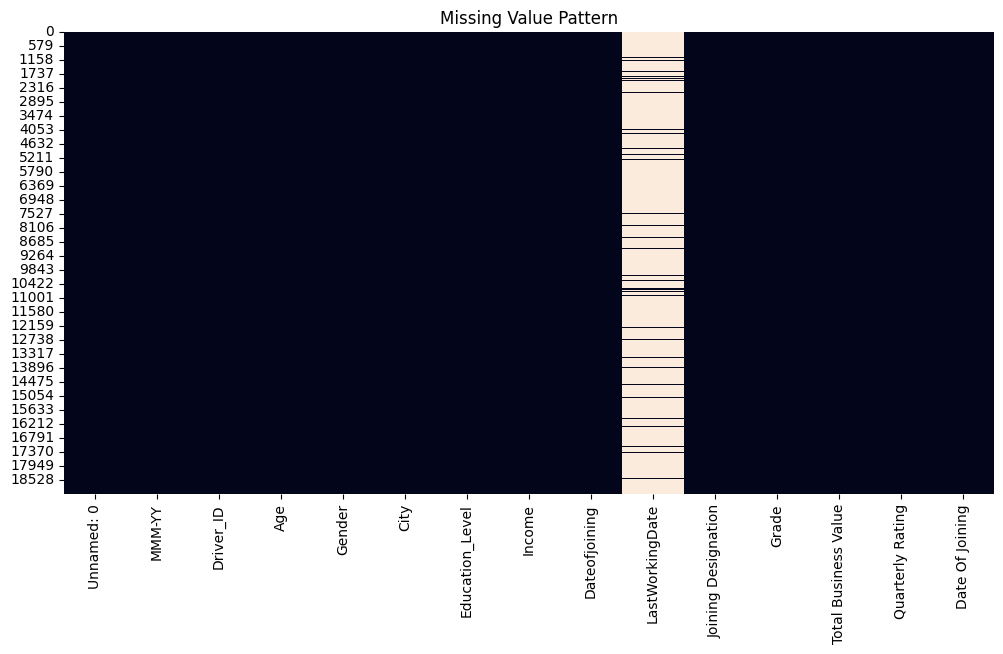

In [ ]:
plt.figure(figsize=(12, 6))

sns.heatmap(df.isnull(), cbar=False)

plt.title("Missing Value Pattern")
plt.show()

*Important observation**

LastWorkingDate contains many missing values.

This is not necessarily bad data.

It means:

The driver is still working.

Therefore, we should not simply delete those rows.

# **Univariate Analysis**

**Age**

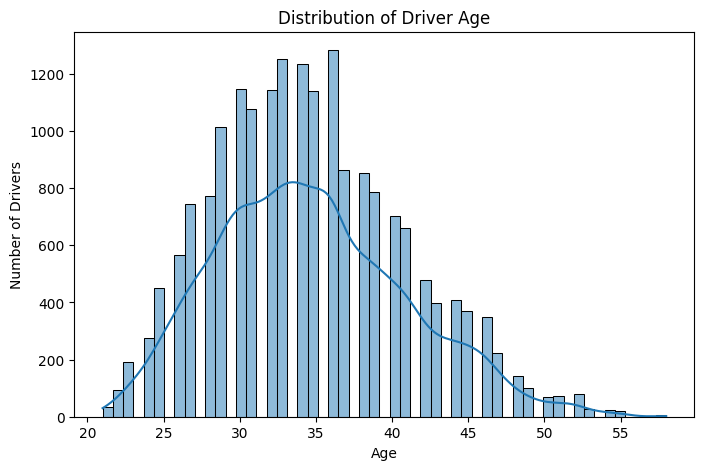

In [ ]:
plt.figure(figsize=(8, 5))

sns.histplot(df["Age"], kde=True)

plt.title("Distribution of Driver Age")
plt.xlabel("Age")
plt.ylabel("Number of Drivers")

plt.show()

**Interpretation**

We are checking:

Typical driver age
Spread
Skewness
Possible extreme ages

**Income Distribution**

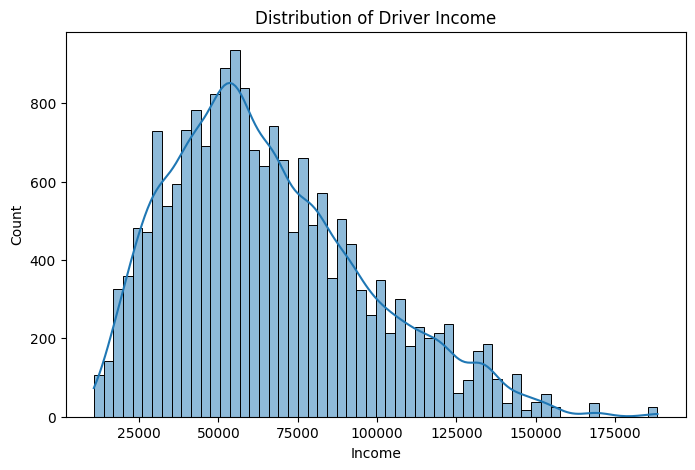

In [ ]:
plt.figure(figsize=(8, 5))

sns.histplot(df["Income"], kde=True)

plt.title("Distribution of Driver Income")
plt.xlabel("Income")

plt.show()

Because income may have extreme values, also use:

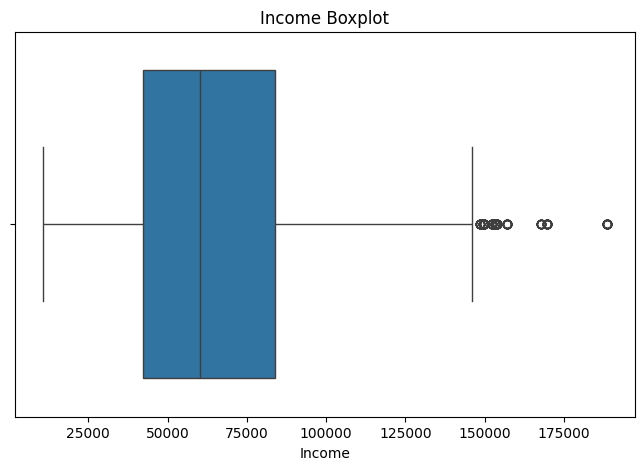

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(x=df["Income"])

plt.title("Income Boxplot")

plt.show()

**Interpretation**

A boxplot helps identify:

Median
Interquartile range
Outliers

**Quarterly Rating**

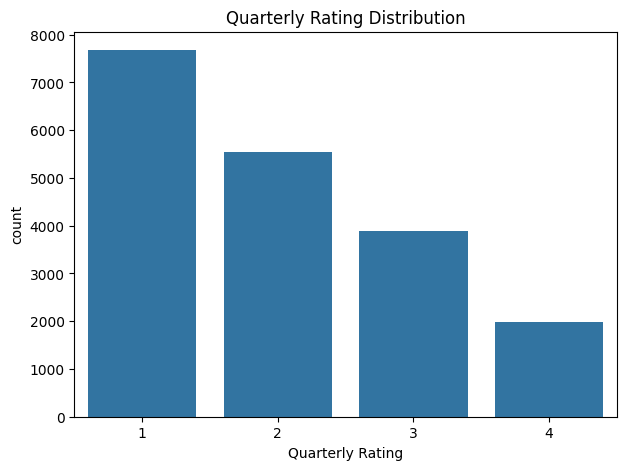

In [ ]:
plt.figure(figsize=(7, 5))

sns.countplot(x="Quarterly Rating", data=df)

plt.title("Quarterly Rating Distribution")

plt.show()

**Interpretation**

The plot tells us whether drivers are concentrated around:

Rating 1

Rating 2

Rating 3

Rating 4

Rating 5

**Grade**

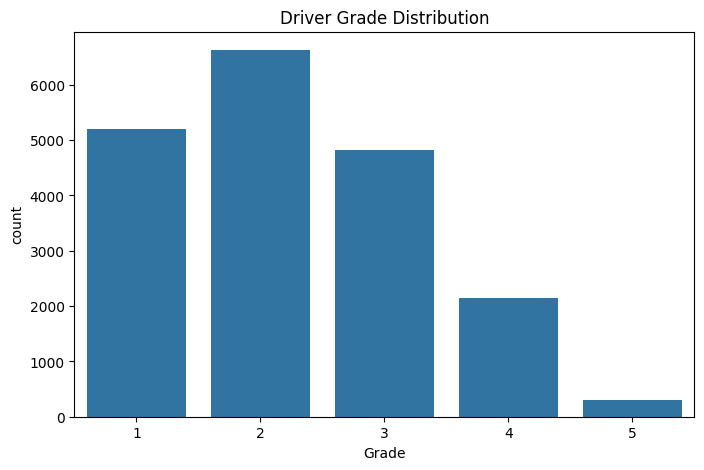

In [ ]:
plt.figure(figsize=(8, 5))

sns.countplot(x="Grade", data=df)

plt.title("Driver Grade Distribution")

plt.show()

**Gender**

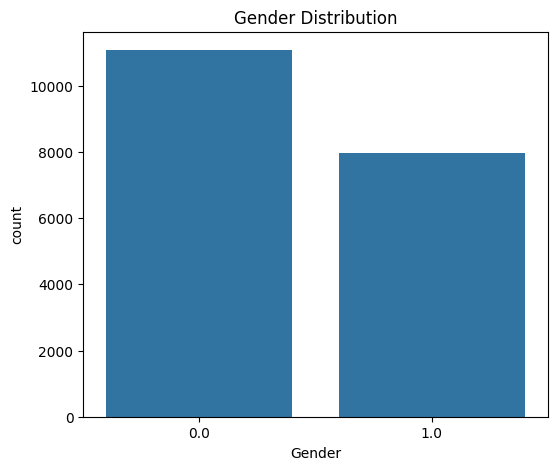

In [ ]:
plt.figure(figsize=(6, 5))

sns.countplot(x="Gender", data=df)

plt.title("Gender Distribution")

plt.show()

0 = Male

1 = Female

**Education Level**

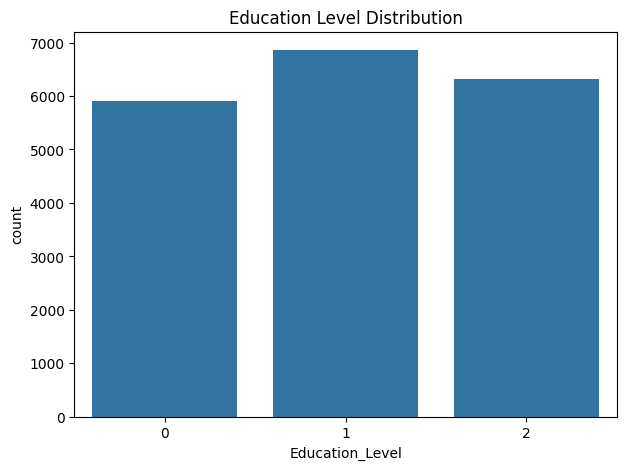

In [ ]:
plt.figure(figsize=(7, 5))

sns.countplot(x="Education_Level", data=df)

plt.title("Education Level Distribution")

plt.show()

**City Distribution**

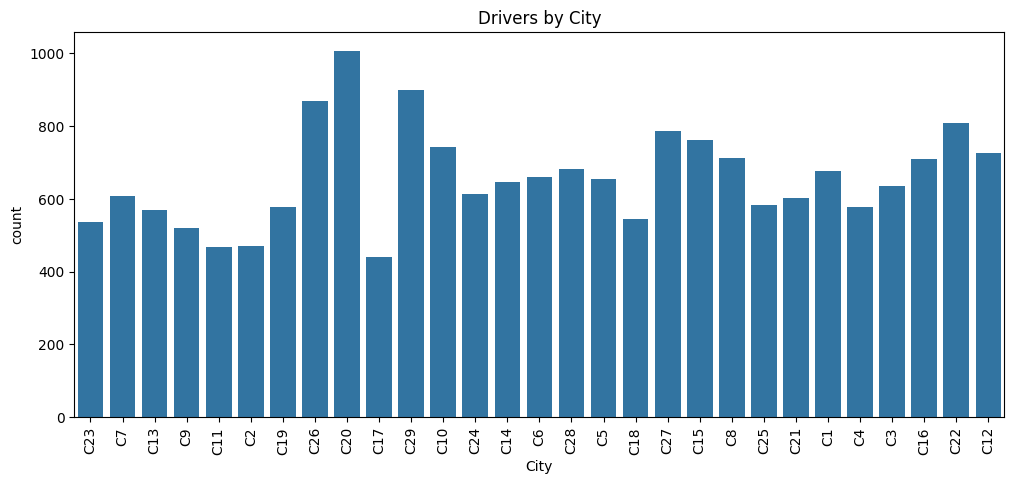

In [ ]:
plt.figure(figsize=(12, 5))

sns.countplot(x="City", data=df)

plt.xticks(rotation=90)

plt.title("Drivers by City")

plt.show()

**Total Business Value**

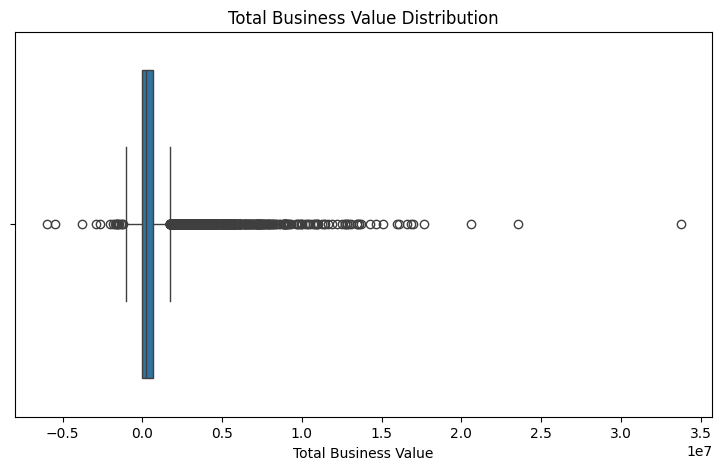

In [ ]:
plt.figure(figsize=(9, 5))

sns.boxplot(x=df["Total Business Value"])

plt.title("Total Business Value Distribution")

plt.show()

Negative Total Business Value can occur because of cancellation/refund or car EMI adjustments.

Therefore, a negative value should not automatically be treated as an error.

**Multiple Rows Per Driver**

A driver appears multiple times, because the dataset contains monthly records.

Our target is:

Did this driver leave?

Therefore, we ultimately need one row per driver.

**Number of Unique Drivers**

In [ ]:
df["Driver_ID"].nunique()

2381

Number of records:

In [ ]:
len(df)

19104

Compare:

In [ ]:
print("Total records:", len(df))
print("Unique drivers:", df["Driver_ID"].nunique())

Total records: 19104
Unique drivers: 2381


This demonstrates why aggregation is required.

# **Feature Engineering**

We will create driver-level features.

Before aggregation, sort the data.

In [ ]:
df = df.sort_values(["Driver_ID", "MMM-YY"])

**Create Rating Increase Variable**

The requirement says:

Create a column that tells whether quarterly rating has increased for the driver.

In [ ]:
df["Rating_Increase"] = (
    df.groupby("Driver_ID")["Quarterly Rating"]
      .diff()
      .fillna(0)
      .gt(0)
      .astype(int)
)

1 means: The rating increased compared with the previous available month.

**Create Income Increase Variable**

In [ ]:
df["Income_Increase"] = (
    df.groupby("Driver_ID")["Income"]
      .diff()
      .fillna(0)
      .gt(0)
      .astype(int)
)

Create Target Variable

The case defines:

Driver whose Last Working Date is present → target = 1.

In [ ]:
df["target"] = df["LastWorkingDate"].notna().astype(int)

Check:

In [ ]:
df["target"].value_counts()

,count
target,
0,17488
1,1616


Percentage:

In [ ]:
df["target"].value_counts(normalize=True) * 100

,proportion
target,
0,91.541039
1,8.458961


Plot:

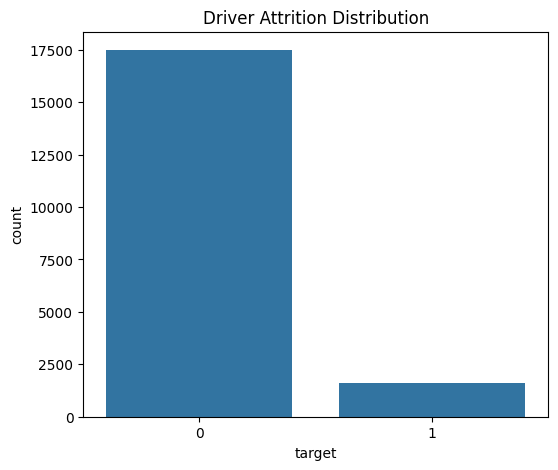

In [ ]:
plt.figure(figsize=(6, 5))

sns.countplot(x="target", data=df)

plt.title("Driver Attrition Distribution")

plt.show()

**Aggregate**

Suppose driver 1001 has 12 monthly records.

If we directly give all 12 rows to the model, the same driver's information appears 12 times.

That can create problems such as:

Data leakage
Artificially large sample size
Incorrect target representation
Poor business interpretation

Therefore:

One driver should correspond to one row in the final modeling dataset.

**Driver-Level Aggregation**

In [ ]:
driver_data = df.groupby("Driver_ID").agg(
    Age=("Age", "last"),
    Gender=("Gender", "last"),
    City=("City", "last"),
    Education_Level=("Education_Level", "last"),
    Income=("Income", "mean"),
    Max_Income=("Income", "max"),
    Joining_Designation=("Joining Designation", "first"),
    Grade=("Grade", "last"),
    Max_Grade=("Grade", "max"),
    Total_Business_Value=("Total Business Value", "sum"),
    Average_Business_Value=("Total Business Value", "mean"),
    Quarterly_Rating=("Quarterly Rating", "last"),
    Average_Quarterly_Rating=("Quarterly Rating", "mean"),
    Max_Quarterly_Rating=("Quarterly Rating", "max"),
    Rating_Increase=("Rating_Increase", "max"),
    Income_Increase=("Income_Increase", "max"),
    Date_Of_Joining=("Dateofjoining", "first"),
    LastWorkingDate=("LastWorkingDate", "last"),
    Reportings=("MMM-YY", "count"),
    target=("target", "max")
).reset_index()

**Check:**

In [ ]:
driver_data.shape

(2381, 21)

In [ ]:
driver_data.head()

,Driver_ID,Age,Gender,City,Education_Level,Income,Max_Income,Joining_Designation,Grade,Max_Grade,...,Average_Business_Value,Quarterly_Rating,Average_Quarterly_Rating,Max_Quarterly_Rating,Rating_Increase,Income_Increase,Date_Of_Joining,LastWorkingDate,Reportings,target
0,1,28.0,0.0,C23,2,57387.0,57387,1,1,1,...,571860.0,2,2.0,2,0,0,24/12/18,2019-03-11,3,1
1,2,31.0,0.0,C7,2,67016.0,67016,2,2,2,...,0.0,1,1.0,1,0,0,11/06/20,NaT,2,0
2,4,43.0,0.0,C13,2,65603.0,65603,2,2,2,...,70000.0,1,1.0,1,0,0,12/07/19,2020-04-27,5,1
3,5,29.0,0.0,C9,0,46368.0,46368,1,1,1,...,40120.0,1,1.0,1,0,0,01/09/19,2019-03-07,3,1
4,6,31.0,1.0,C11,1,78728.0,78728,3,3,3,...,253000.0,2,1.6,2,1,0,31/07/20,NaT,5,0


**Create Tenure**

In [ ]:
reference_date = df["MMM-YY"].max()

driver_data["Date_Of_Joining"] = pd.to_datetime(driver_data["Date_Of_Joining"])

driver_data["Tenure_Days"] = (
    driver_data["LastWorkingDate"].fillna(reference_date)
    - driver_data["Date_Of_Joining"]
).dt.days

Convert to years:

In [ ]:
driver_data["Tenure_Years"] = driver_data["Tenure_Days"] / 365

Create Year of Joining

This is often useful because newer drivers may have different attrition patterns.

In [ ]:
driver_data["Year_of_Joining"] = (
    driver_data["Date_Of_Joining"].dt.year
)

**Statistical Summary of Derived Dataset**

In [ ]:
driver_data.describe().T

,count,mean,min,25%,50%,75%,max,std
Driver_ID,2381.0,1397.559009,1.0,695.0,1400.0,2100.0,2788.0,806.161628
Age,2381.0,33.663167,21.0,29.0,33.0,37.0,58.0,5.983375
Gender,2381.0,0.410332,0.0,0.0,0.0,1.0,1.0,0.491997
Education_Level,2381.0,1.00756,0.0,0.0,1.0,2.0,2.0,0.81629
Income,2381.0,59232.460484,10747.0,39104.0,55285.0,75835.0,188418.0,28298.214012
Max_Income,2381.0,59336.159597,10747.0,39104.0,55315.0,75986.0,188418.0,28383.012146
Joining_Designation,2381.0,1.820244,1.0,1.0,2.0,2.0,5.0,0.841433
Grade,2381.0,2.096598,1.0,1.0,2.0,3.0,5.0,0.941522
Max_Grade,2381.0,2.097018,1.0,1.0,2.0,3.0,5.0,0.941702
Total_Business_Value,2381.0,4586741.822764,-1385530.0,0.0,817680.0,4173650.0,95331060.0,9127115.313446


**Categorical summary:**

In [ ]:
driver_data.describe(include="object").T

,count,unique,top,freq
City,2381,29,C20,152


**Check Missing Values Again**

In [ ]:
driver_data.isnull().sum().sort_values(ascending=False)

,0
LastWorkingDate,765
Driver_ID,0
Gender,0
Age,0
Education_Level,0
Income,0
Max_Income,0
City,0
Joining_Designation,0
Grade,0


Percentage:

In [ ]:
driver_data.isnull().mean().sort_values(ascending=False) * 100

,0
LastWorkingDate,32.129357
Driver_ID,0.000000
Gender,0.000000
Age,0.000000
Education_Level,0.000000
Income,0.000000
Max_Income,0.000000
City,0.000000
Joining_Designation,0.000000
Grade,0.000000


**Correlation Analysis**

Select numerical columns:

In [ ]:
numeric_cols = driver_data.select_dtypes(
    include=np.number
).columns

Correlation matrix:

In [ ]:
corr = driver_data[numeric_cols].corr()

Plot:

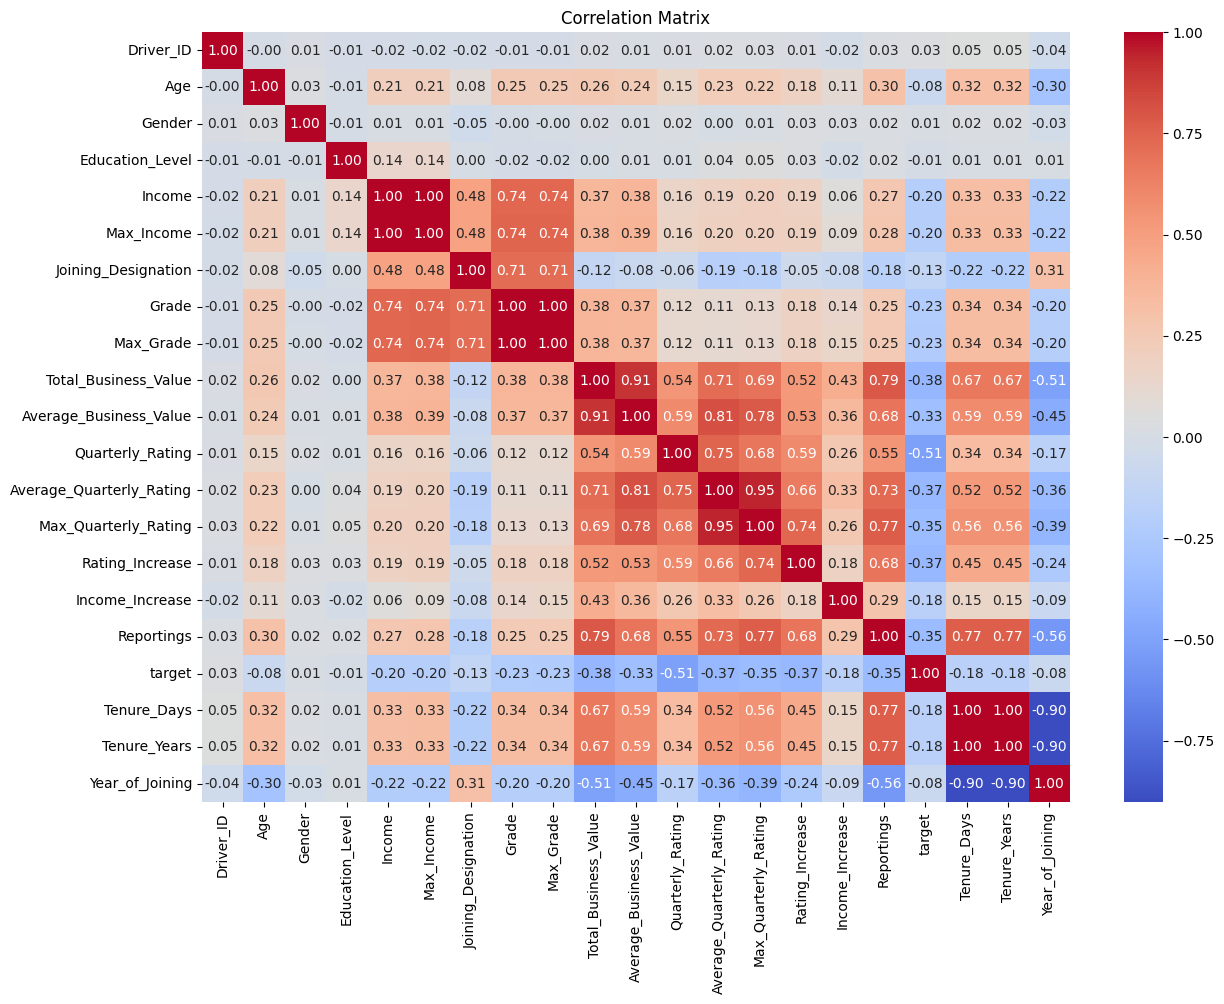

In [ ]:
plt.figure(figsize=(14, 10))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

Rating_Increase and target have a negative correlation, drivers whose ratings improve may have lower attrition.

# **Bivariate Analysis**

**Income vs Attrition**

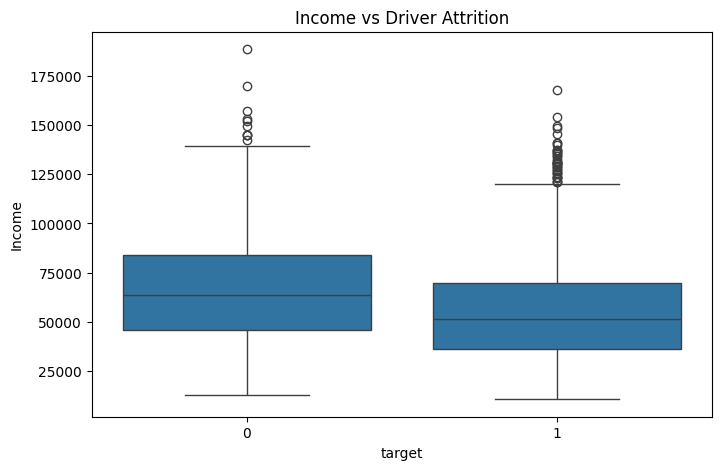

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    x="target",
    y="Income",
    data=driver_data
)

plt.title("Income vs Driver Attrition")

plt.show()

**Rating vs Attrition**

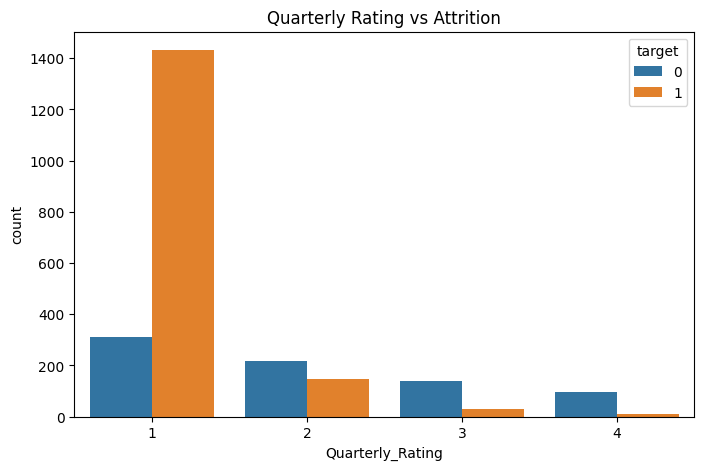

In [ ]:
plt.figure(figsize=(8, 5))

sns.countplot(
    x="Quarterly_Rating",
    hue="target",
    data=driver_data
)

plt.title("Quarterly Rating vs Attrition")

plt.show()

**Grade vs Attrition**

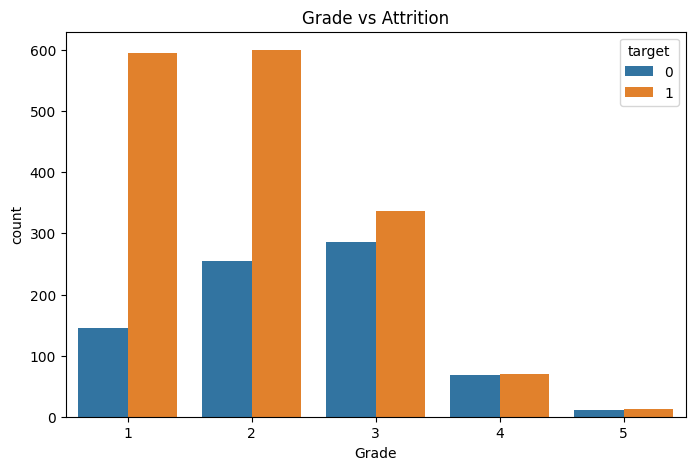

In [ ]:
plt.figure(figsize=(8, 5))

sns.countplot(
    x="Grade",
    hue="target",
    data=driver_data
)

plt.title("Grade vs Attrition")

plt.show()

**City vs Attrition**

In [ ]:
city_attrition = pd.crosstab(
    driver_data["City"],
    driver_data["target"],
    normalize="index"
) * 100

city_attrition.sort_values(
    by=1,
    ascending=False
).head(15)

target,0,1
City,,
C13,18.309859,81.690141
C17,22.535211,77.464789
C23,22.972973,77.027027
C2,23.611111,76.388889
C14,26.582278,73.417722
C20,26.973684,73.026316
C25,27.027027,72.972973
C28,28.048780,71.951220
C10,29.069767,70.930233


Plot:

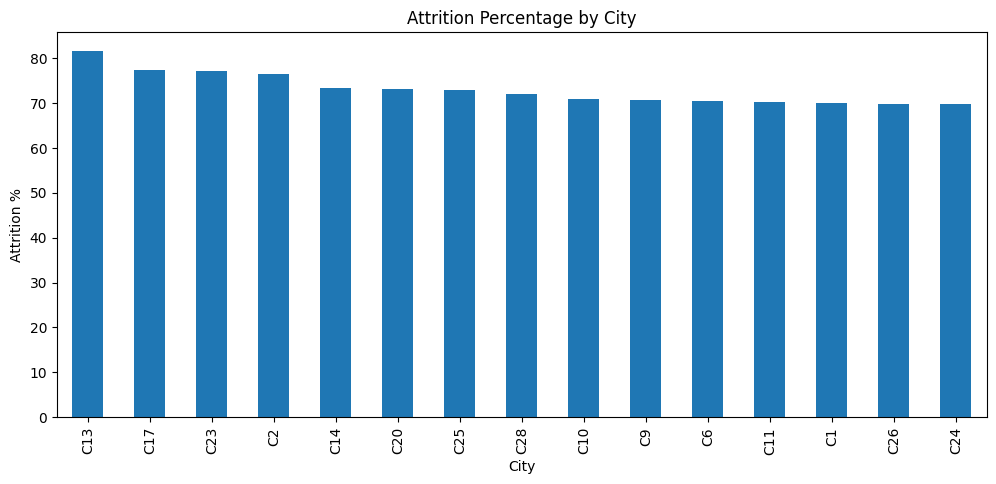

In [ ]:
city_attrition[1].sort_values(ascending=False).head(15).plot(
    kind="bar",
    figsize=(12, 5)
)

plt.title("Attrition Percentage by City")
plt.ylabel("Attrition %")
plt.show()

This is more useful than simply counting churned drivers because cities may have different numbers of drivers.

**Rating Increase vs Attrition**

In [ ]:
pd.crosstab(
    driver_data["Rating_Increase"],
    driver_data["target"],
    normalize="index"
) * 100

target,0,1
Rating_Increase,,
0,19.512195,80.487805
1,56.014581,43.985419


Plot:

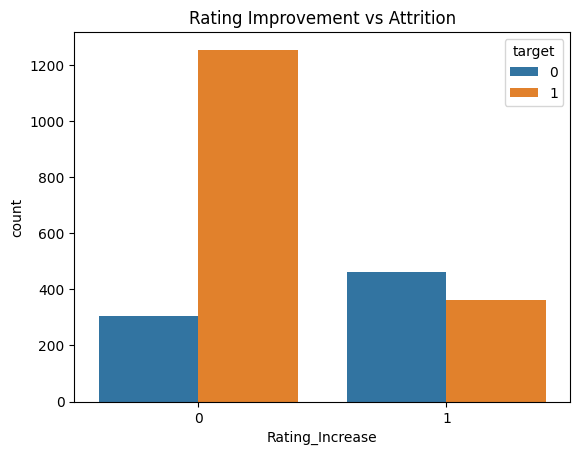

In [ ]:
sns.countplot(
    x="Rating_Increase",
    hue="target",
    data=driver_data
)

plt.title("Rating Improvement vs Attrition")

plt.show()

**Income Increase vs Attrition**

# **Create Final Modeling Dataset**

We should remove columns that should not directly enter the model.

Important columns to remove:

Driver_ID
LastWorkingDate
Date_Of_Joining

because the target itself was created using LastWorkingDate.

If we leave it in the model, that would be target leakage.

In [ ]:
model_data = driver_data.drop(
    columns=[
        "Driver_ID",
        "LastWorkingDate",
        "Date_Of_Joining",
        "Tenure_Days"
    ]
)

**Separate X and y**

In [ ]:
X = model_data.drop("target", axis=1)

y = model_data["target"]

Check:

In [ ]:
print(X.shape)
print(y.shape)

(2381, 19)
(2381,)


**Identify Categorical Columns**

In [ ]:
X.select_dtypes(include="object").columns

Index(['City'], dtype='object')

**Convert Categorical Variables to Category**

In [ ]:
for col in X.select_dtypes(include="object").columns:
    X[col] = X[col].astype("category")

# **One-Hot Encoding**

In [ ]:
X = pd.get_dummies(
    X,
    columns=X.select_dtypes(include="category").columns,
    drop_first=True
)

Check:

In [ ]:
X.head()

,Age,Gender,Education_Level,Income,Max_Income,Joining_Designation,Grade,Max_Grade,Total_Business_Value,Average_Business_Value,...,City_C27,City_C28,City_C29,City_C3,City_C4,City_C5,City_C6,City_C7,City_C8,City_C9
0,28.0,0.0,2,57387.0,57387,1,1,1,1715580,571860.0,...,False,False,False,False,False,False,False,False,False,False
1,31.0,0.0,2,67016.0,67016,2,2,2,0,0.0,...,False,False,False,False,False,False,False,True,False,False
2,43.0,0.0,2,65603.0,65603,2,2,2,350000,70000.0,...,False,False,False,False,False,False,False,False,False,False
3,29.0,0.0,0,46368.0,46368,1,1,1,120360,40120.0,...,False,False,False,False,False,False,False,False,False,True
4,31.0,1.0,1,78728.0,78728,3,3,3,1265000,253000.0,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
X.shape

(2381, 46)

**KNN Imputation**

We should not calculate KNN imputation using the entire dataset before train/test split because information from the test set can leak into the training process.

So first split.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

**KNN Imputer**

In [ ]:
imputer = KNNImputer(n_neighbors=5)

X_train_imputed = imputer.fit_transform(X_train)

X_test_imputed = imputer.transform(X_test)

Convert back to DataFrame:

In [ ]:
X_train = pd.DataFrame(
    X_train_imputed,
    columns=X_train.columns,
    index=X_train.index
)

X_test = pd.DataFrame(
    X_test_imputed,
    columns=X_test.columns,
    index=X_test.index
)

Check:

In [ ]:
X_train.isnull().sum().sum()

np.int64(0)

# **Standardization**
Although Random Forest itself does not require standardization, the case specifically asks for it and it is good practice for algorithms affected by feature scale.

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

Convert:

In [ ]:
X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns,
    index=X_test.index
)

**Check Class Imbalance**

In [ ]:
print(y_train.value_counts())

target
1    1292
0     612
Name: count, dtype: int64


Percentage:

In [ ]:
print(y_train.value_counts(normalize=True) * 100)

target
1    67.857143
0    32.142857
Name: proportion, dtype: float64


Visualize:

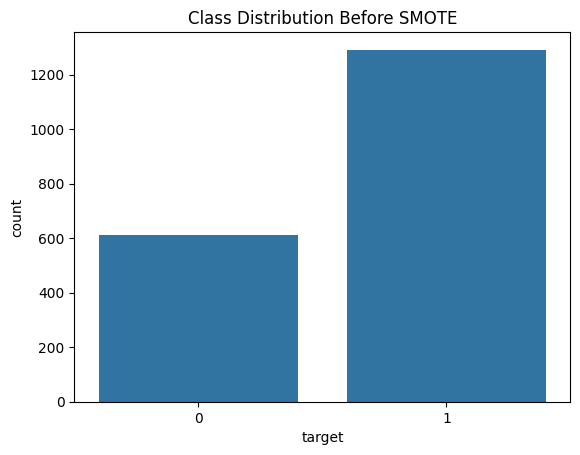

In [ ]:
sns.countplot(x=y_train)

plt.title("Class Distribution Before SMOTE")

plt.show()

# **SMOTE**

In [ ]:
smote = SMOTE(random_state=42)

X_train_balanced, y_train_balanced = smote.fit_resample(
    X_train_scaled,
    y_train
)

Check:

In [ ]:
print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(pd.Series(y_train_balanced).value_counts())

Before SMOTE:
target
1    1292
0     612
Name: count, dtype: int64

After SMOTE:
target
0    1292
1    1292
Name: count, dtype: int64


# **Ensemble Model 1 — Bagging**

**Random Forest**

Random Forest is an ensemble of multiple decision trees.

**Basic Random Forest**

In [ ]:
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced"
)

rf.fit(
    X_train_balanced,
    y_train_balanced
)

RandomForestClassifier(class_weight='balanced', n_estimators=300,
                       random_state=42)

Predictions:

In [ ]:
rf_pred = rf.predict(X_test_scaled)

Probability:

In [ ]:
rf_prob = rf.predict_proba(X_test_scaled)[:, 1]

# **Random Forest Evaluation**

In [ ]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.90      0.84      0.87       153
           1       0.93      0.95      0.94       324

    accuracy                           0.92       477
   macro avg       0.91      0.90      0.90       477
weighted avg       0.92      0.92      0.92       477



Confusion matrix:

In [ ]:
cm_rf = confusion_matrix(y_test, rf_pred)

print(cm_rf)

[[129  24]
 [ 15 309]]


Visualize:

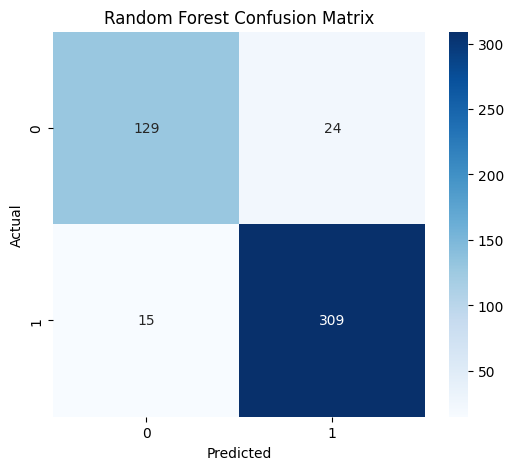

In [ ]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Random Forest Confusion Matrix")

plt.show()

**Random Forest ROC-AUC**

In [ ]:
rf_auc = roc_auc_score(
    y_test,
    rf_prob
)

print("Random Forest ROC-AUC:", rf_auc)

Random Forest ROC-AUC: 0.9639312515129509


# **Ensemble Model 2 — Boosting**

**Gradient Boosting**

In [ ]:
gb = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb.fit(
    X_train_balanced,
    y_train_balanced
)

GradientBoostingClassifier(learning_rate=0.05, n_estimators=200,
                           random_state=42)

Prediction:

In [ ]:
gb_pred = gb.predict(X_test_scaled)

gb_prob = gb.predict_proba(X_test_scaled)[:, 1]

**Gradient Boosting Evaluation**

In [ ]:
print(classification_report(y_test, gb_pred))

              precision    recall  f1-score   support

           0       0.88      0.88      0.88       153
           1       0.94      0.94      0.94       324

    accuracy                           0.92       477
   macro avg       0.91      0.91      0.91       477
weighted avg       0.92      0.92      0.92       477



Confusion matrix:

In [ ]:
cm_gb = confusion_matrix(y_test, gb_pred)

print(cm_gb)

[[135  18]
 [ 19 305]]


Plot:

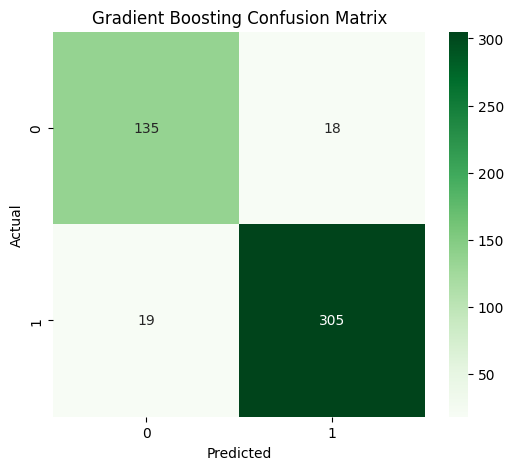

In [ ]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_gb,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Gradient Boosting Confusion Matrix")

plt.show()

**Gradient Boosting ROC-AUC**

In [ ]:
gb_auc = roc_auc_score(
    y_test,
    gb_prob
)

print("Gradient Boosting ROC-AUC:", gb_auc)

Gradient Boosting ROC-AUC: 0.9676631969660292


**ROC Curves — Compare Models**

In [ ]:
rf_fpr, rf_tpr, _ = roc_curve(
    y_test,
    rf_prob
)

gb_fpr, gb_tpr, _ = roc_curve(
    y_test,
    gb_prob
)

Plot:

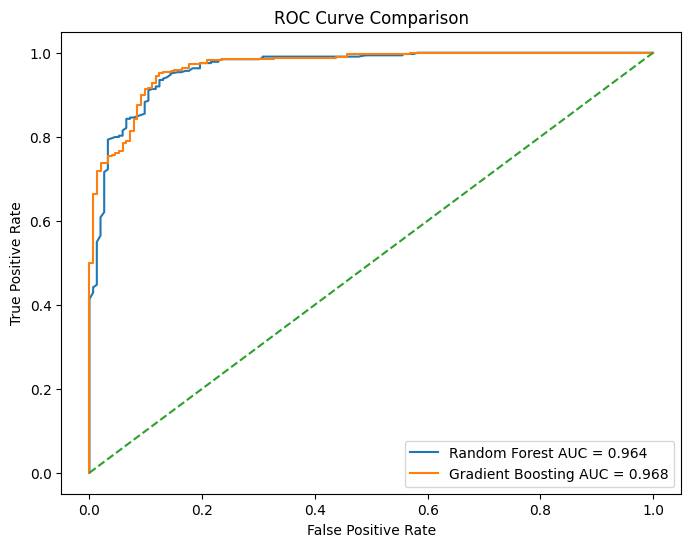

In [ ]:
plt.figure(figsize=(8, 6))

plt.plot(
    rf_fpr,
    rf_tpr,
    label=f"Random Forest AUC = {rf_auc:.3f}"
)

plt.plot(
    gb_fpr,
    gb_tpr,
    label=f"Gradient Boosting AUC = {gb_auc:.3f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")

plt.legend()

plt.show()

**Create Model Comparison Table**

In [ ]:
results = pd.DataFrame({
    "Model": [
        "Random Forest",
        "Gradient Boosting"
    ],

    "Accuracy": [
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, gb_pred)
    ],

    "Precision": [
        precision_score(y_test, rf_pred),
        precision_score(y_test, gb_pred)
    ],

    "Recall": [
        recall_score(y_test, rf_pred),
        recall_score(y_test, gb_pred)
    ],

    "F1": [
        f1_score(y_test, rf_pred),
        f1_score(y_test, gb_pred)
    ],

    "ROC_AUC": [
        rf_auc,
        gb_auc
    ]
})

results

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Random Forest,0.918239,0.927928,0.953704,0.940639,0.963931
1,Gradient Boosting,0.922432,0.944272,0.941358,0.942813,0.967663


**Feature Importance — Random Forest**

In [ ]:
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

Top 15:

In [ ]:
importance.head(15)

,Feature,Importance
17,Year_of_Joining,0.170005
10,Quarterly_Rating,0.118271
16,Tenure_Years,0.091593
15,Reportings,0.080055
8,Total_Business_Value,0.061368
9,Average_Business_Value,0.048308
4,Max_Income,0.042164
11,Average_Quarterly_Rating,0.039609
3,Income,0.039433
0,Age,0.038282


Plot:

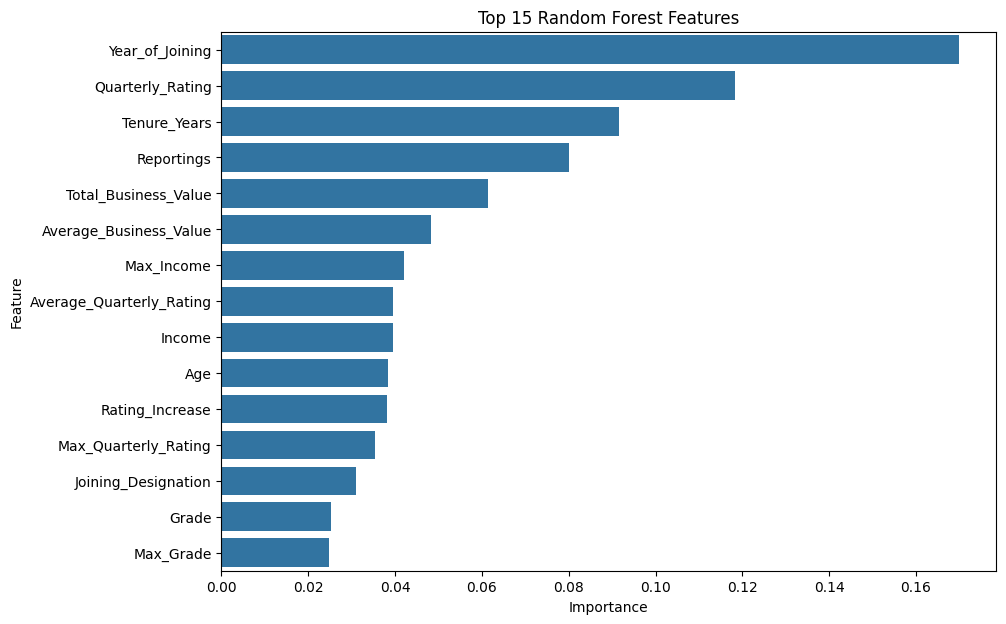

In [ ]:
plt.figure(figsize=(10, 7))

sns.barplot(
    data=importance.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Random Forest Features")

plt.show()

**Feature Importance — Gradient Boosting**

In [ ]:
gb_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": gb.feature_importances_
})

gb_importance = gb_importance.sort_values(
    "Importance",
    ascending=False
)

gb_importance.head(15)

,Feature,Importance
10,Quarterly_Rating,0.380086
17,Year_of_Joining,0.344589
15,Reportings,0.131606
16,Tenure_Years,0.053186
9,Average_Business_Value,0.013350
8,Total_Business_Value,0.012738
1,Gender,0.011797
2,Education_Level,0.010612
5,Joining_Designation,0.009214
13,Rating_Increase,0.006094


**Hyperparameter Tuning — Random Forest**

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

rf_model = RandomForestClassifier(
    random_state=42,
    class_weight="balanced"
)

param_grid = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [3, 5, 8, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

In [ ]:
rf_search = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=param_grid,
    n_iter=20,
    scoring="roc_auc",
    cv=5,
    random_state=42,
    n_jobs=-1
)

rf_search.fit(
    X_train_balanced,
    y_train_balanced
)

RandomizedSearchCV(cv=5,
                   estimator=RandomForestClassifier(class_weight='balanced',
                                                    random_state=42),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'max_depth': [3, 5, 8, 10, None],
                                        'max_features': ['sqrt', 'log2'],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300, 500]},
                   random_state=42, scoring='roc_auc')

Best parameters:

In [ ]:
rf_search.best_params_

{'n_estimators': 300,
 'min_samples_split': 2,
 'min_samples_leaf': 2,
 'max_features': 'sqrt',
 'max_depth': None}

Best score:

In [ ]:
rf_search.best_score_

np.float64(0.9664950896968204)

**Tuned Random Forest**

In [ ]:
best_rf = rf_search.best_estimator_

best_rf_pred = best_rf.predict(X_test_scaled)

best_rf_prob = best_rf.predict_proba(
    X_test_scaled
)[:, 1]

Evaluation:

In [ ]:
print(classification_report(
    y_test,
    best_rf_pred
))

              precision    recall  f1-score   support

           0       0.89      0.86      0.87       153
           1       0.93      0.95      0.94       324

    accuracy                           0.92       477
   macro avg       0.91      0.90      0.91       477
weighted avg       0.92      0.92      0.92       477



ROC-AUC:

In [ ]:
best_rf_auc = roc_auc_score(
    y_test,
    best_rf_prob
)

print(best_rf_auc)

0.9627410635035907


**Hyperparameter Tuning — Gradient Boosting**

In [ ]:
gb_model = GradientBoostingClassifier(
    random_state=42
)

gb_params = {
    "n_estimators": [100, 150, 200, 300],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "max_depth": [2, 3, 4],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

In [ ]:
gb_search = RandomizedSearchCV(
    estimator=gb_model,
    param_distributions=gb_params,
    n_iter=20,
    scoring="roc_auc",
    cv=5,
    random_state=42,
    n_jobs=-1
)

gb_search.fit(
    X_train_balanced,
    y_train_balanced
)

RandomizedSearchCV(cv=5, estimator=GradientBoostingClassifier(random_state=42),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'learning_rate': [0.01, 0.03, 0.05,
                                                          0.1],
                                        'max_depth': [2, 3, 4],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 150, 200, 300]},
                   random_state=42, scoring='roc_auc')

Best parameters:

In [ ]:
gb_search.best_params_

{'n_estimators': 200,
 'min_samples_split': 5,
 'min_samples_leaf': 2,
 'max_depth': 4,
 'learning_rate': 0.1}

**Tuned Gradient Boosting**

In [ ]:
best_gb = gb_search.best_estimator_

best_gb_pred = best_gb.predict(X_test_scaled)

best_gb_prob = best_gb.predict_proba(
    X_test_scaled
)[:, 1]

**Classification report:**

In [ ]:
print(classification_report(
    y_test,
    best_gb_pred
))

              precision    recall  f1-score   support

           0       0.88      0.86      0.87       153
           1       0.93      0.94      0.94       324

    accuracy                           0.92       477
   macro avg       0.91      0.90      0.90       477
weighted avg       0.92      0.92      0.92       477



**ROC-AUC:**

In [ ]:
best_gb_auc = roc_auc_score(
    y_test,
    best_gb_prob
)

print("Gradient Boosting AUC:", best_gb_auc)

Gradient Boosting AUC: 0.9687726942628904


# **Final Model Comparison**

In [ ]:
final_results = pd.DataFrame({
    "Model": [
        "Random Forest",
        "Tuned Random Forest",
        "Gradient Boosting",
        "Tuned Gradient Boosting"
    ],

    "Accuracy": [
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, best_rf_pred),
        accuracy_score(y_test, gb_pred),
        accuracy_score(y_test, best_gb_pred)
    ],

    "Precision": [
        precision_score(y_test, rf_pred),
        precision_score(y_test, best_rf_pred),
        precision_score(y_test, gb_pred),
        precision_score(y_test, best_gb_pred)
    ],

    "Recall": [
        recall_score(y_test, rf_pred),
        recall_score(y_test, best_rf_pred),
        recall_score(y_test, gb_pred),
        recall_score(y_test, best_gb_pred)
    ],

    "F1": [
        f1_score(y_test, rf_pred),
        f1_score(y_test, best_rf_pred),
        f1_score(y_test, gb_pred),
        f1_score(y_test, best_gb_pred)
    ],

    "ROC_AUC": [
        rf_auc,
        best_rf_auc,
        gb_auc,
        best_gb_auc
    ]
})

final_results

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Random Forest,0.918239,0.927928,0.953704,0.940639,0.963931
1,Tuned Random Forest,0.920335,0.933333,0.950617,0.941896,0.962741
2,Gradient Boosting,0.922432,0.944272,0.941358,0.942813,0.967663
3,Tuned Gradient Boosting,0.916143,0.932927,0.944444,0.938650,0.968773


Are drivers whose ratings fail to improve more likely to leave?

In [ ]:
pd.crosstab(
    driver_data["Rating_Increase"],
    driver_data["target"],
    normalize="index"
) * 100

target,0,1
Rating_Increase,,
0,19.512195,80.487805
1,56.014581,43.985419


Are drivers with lower income more likely to leave?

In [ ]:
driver_data.groupby("target")["Income"].median()

,Income
target,
0,63632.0
1,51630.0


Does income improvement appear to be associated with retention?

In [ ]:
pd.crosstab(
    driver_data["Income_Increase"],
    driver_data["target"],
    normalize="index"
) * 100

target,0,1
Income_Increase,,
0,30.979889,69.020111
1,93.181818,6.818182


Are newer drivers leaving more frequently?

In [ ]:
driver_data.groupby("target")["Tenure_Years"].median()

,Tenure_Years
target,
0,0.580822
1,0.482192


Are some cities experiencing substantially different attrition rates?

In [ ]:
city_attrition.sort_values(
    by=1,
    ascending=False
).head(10)

target,0,1
City,,
C13,18.309859,81.690141
C17,22.535211,77.464789
C23,22.972973,77.027027
C2,23.611111,76.388889
C14,26.582278,73.417722
C20,26.973684,73.026316
C25,27.027027,72.972973
C28,28.048780,71.951220
C10,29.069767,70.930233


Grade

In [ ]:
pd.crosstab(
    driver_data["Grade"],
    driver_data["target"],
    normalize="index"
) * 100

target,0,1
Grade,,
1,19.568151,80.431849
2,29.824561,70.175439
3,45.906902,54.093098
4,49.275362,50.724638
5,45.833333,54.166667


In [ ]:
!ls

ola_driver_scaler.csv  sample_data


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!jupyter nbconvert --to html "/content/drive/MyDrive/Colab Notebooks/OLA - Ensemble Learning-Heena"

[NbConvertApp] Converting notebook /content/drive/MyDrive/Colab Notebooks/OLA - Ensemble Learning-Heena to html
[NbConvertApp] WARNING | Alternative text is missing on 22 image(s).
[NbConvertApp] Writing 1714580 bytes to /content/drive/MyDrive/Colab Notebooks/OLA - Ensemble Learning-Heen.html
